# Training Projection Accuracy

Loading experiment data...
Loading: data/accuracy_run_optimize/optimization_exp_all_data_seed0.pickle
Loading: data/accuracy_run_optimize/optimization_exp_all_data_seed1.pickle
Loading: data/accuracy_run_optimize/optimization_exp_all_data_seed2.pickle
Loading: data/accuracy_run_optimize/optimization_exp_all_data_seed3.pickle
Loading: data/accuracy_run_optimize/optimization_exp_all_data_seed4.pickle
No data found for seed 5
Successfully loaded 37 data points
Data saved to 'accuracy_cosine_analysis.csv'


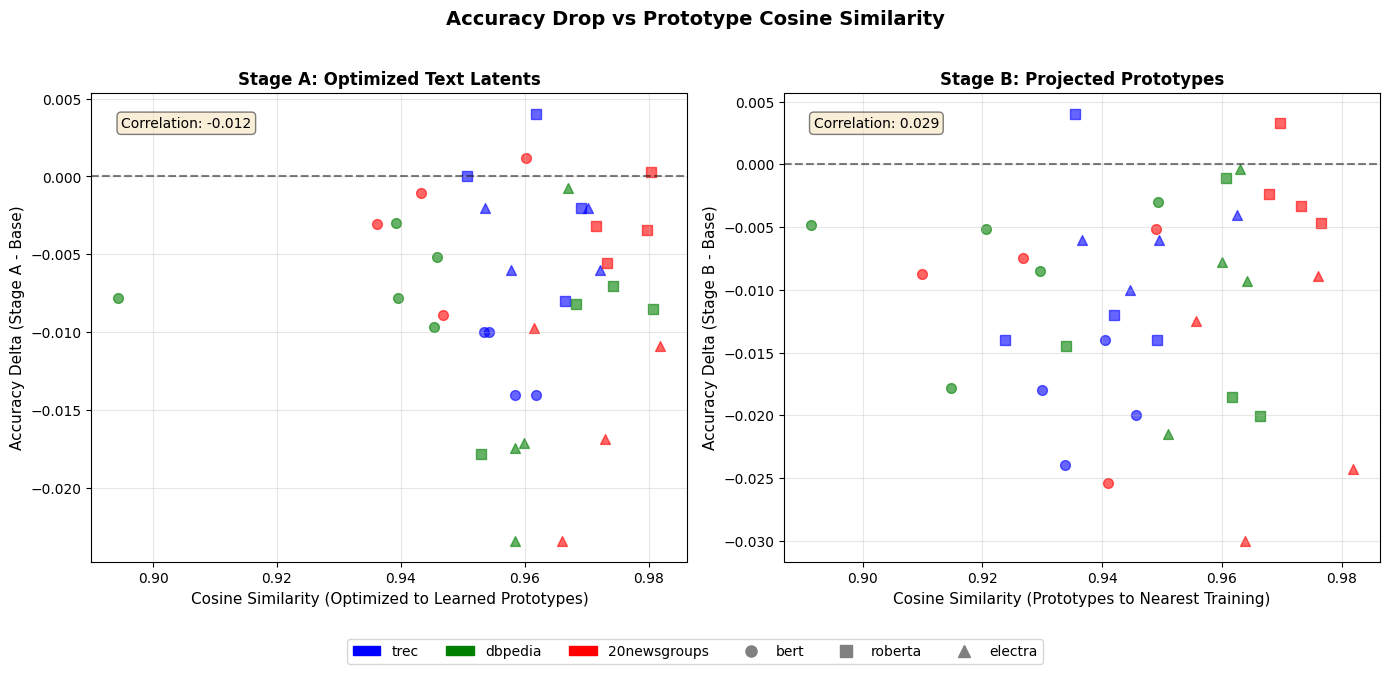


=== Summary Statistics ===
Total data points: 37
Seeds found: [0, 1, 2, 3, 4]
Datasets: ['20newsgroups', 'dbpedia', 'trec']
Models: ['bert', 'electra', 'roberta']

=== Stage A Statistics ===
Mean accuracy delta: -0.0078
Mean cosine similarity (optimized to proto): 0.9591

=== Stage B Statistics ===
Mean accuracy delta: -0.0108
Mean cosine similarity (proto to nearest train): 0.9473

=== Best Stage A Performance (smallest accuracy drop) ===
     dataset   model  seed  stageA_delta  cosine_optimized_to_proto
        trec roberta     1      0.004000                   0.961770
20newsgroups    bert     4      0.001195                   0.960235
20newsgroups roberta     3      0.000266                   0.980392

=== Worst Stage A Performance (largest accuracy drop) ===
     dataset   model  seed  stageA_delta  cosine_optimized_to_proto
     dbpedia electra     1     -0.023368                   0.958364
20newsgroups electra     1     -0.023367                   0.965962
     dbpedia roberta

In [5]:
#!/usr/bin/env python3
"""
Plot the relationship between accuracy drop and cosine similarity
for Stage A and Stage B prototypes across all dataset-model combinations and seeds.
"""

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

def load_experiment_data():
    """Load all experiment data across seeds."""
    datasets = ['trec', 'dbpedia', '20newsgroups']
    models = ['bert', 'roberta', 'electra']
    seeds = [0, 1, 2,3,4,5]  # Try all these seeds
    
    all_data = []
    
    for seed in seeds:
        # Try both possible paths
        paths_to_try = [
            f'data/accuracy_run_optimize/optimization_exp_all_data_seed{seed}.pickle',
            # f'data/optimization_exp_all_data_seed{seed}_agnews.pickle'
        ]
        
        data_loaded = False
        for pickle_path in paths_to_try:
            if os.path.exists(pickle_path):
                print(f"Loading: {pickle_path}")
                try:
                    with open(pickle_path, 'rb') as f:
                        exp_data = pickle.load(f)
                    data_loaded = True
                    break
                except Exception as e:
                    print(f"Error loading {pickle_path}: {e}")
                    continue
        
        if not data_loaded:
            print(f"No data found for seed {seed}")
            continue
            
        # Extract data for each dataset-model combination
        for dataset in datasets:
            for model in models:
                # Try different key formats
                keys_to_try = [
                    f'{dataset}_{model}_latent_optim_3llms',
                    f'{dataset}_{model}_latent_optim_1llms',
                ]
                
                summary_keys_to_try = [
                    f'{dataset}_{model}_latent_optim_3llms_summary',
                    f'{dataset}_{model}_latent_optim_1llms_summary',
                ]
                
                # Find the right keys
                for key, summary_key in zip(keys_to_try, summary_keys_to_try):
                    if summary_key in exp_data:
                        summary = exp_data[summary_key]
                        
                        # Extract metrics
                        base_acc = summary['base_metrics']['accuracy']
                        stageA_acc = summary['stageA_metrics_optimized_text_latents']['accuracy']
                        stageB_acc = summary['stageB_metrics_projected']['accuracy']
                        
                        # Cosine similarities
                        avg_cosine_optimized_to_proto = summary.get('avg_cosine_optimized_to_proto', np.nan)
                        avg_cosine_proto_to_nearest_train = summary.get('avg_cosine_proto_to_nearest_train', np.nan)
                        
                        # Calculate accuracy drops (negative means performance dropped)
                        stageA_delta = stageA_acc - base_acc
                        stageB_delta = stageB_acc - base_acc
                        
                        all_data.append({
                            'seed': seed,
                            'dataset': dataset,
                            'model': model,
                            'base_acc': base_acc,
                            'stageA_acc': stageA_acc,
                            'stageB_acc': stageB_acc,
                            'stageA_delta': stageA_delta,
                            'stageB_delta': stageB_delta,
                            'cosine_optimized_to_proto': avg_cosine_optimized_to_proto,
                            'cosine_proto_to_nearest_train': avg_cosine_proto_to_nearest_train,
                        })
                        break  # Found data for this combination
    
    return pd.DataFrame(all_data)

def create_plots(df):
    """Create scatter plots showing relationship between accuracy delta and cosine similarity."""
    
    if df.empty:
        print("No data to plot!")
        return
    
    # Set up the plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Define colors for each dataset and markers for each model
    dataset_colors = {
        'trec': 'blue',
        'dbpedia': 'green', 
        '20newsgroups': 'red'
    }
    
    model_markers = {
        'bert': 'o',
        'roberta': 's',
        'electra': '^'
    }
    
    # Plot 1: Stage A - Optimized text latents
    ax1 = axes[0]
    for dataset in df['dataset'].unique():
        for model in df['model'].unique():
            mask = (df['dataset'] == dataset) & (df['model'] == model)
            data = df[mask]
            if not data.empty:
                ax1.scatter(
                    data['cosine_optimized_to_proto'],
                    data['stageA_delta'],
                    c=dataset_colors.get(dataset, 'gray'),
                    marker=model_markers.get(model, 'o'),
                    s=50,
                    alpha=0.6,
                    label=f'{dataset}-{model}'
                )
    
    ax1.set_xlabel('Cosine Similarity (Optimized to Learned Prototypes)', fontsize=11)
    ax1.set_ylabel('Accuracy Delta (Stage A - Base)', fontsize=11)
    ax1.set_title('Stage A: Optimized Text Latents', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Add correlation if enough data
    valid_data = df[['cosine_optimized_to_proto', 'stageA_delta']].dropna()
    if len(valid_data) > 2:
        corr = valid_data.corr().iloc[0, 1]
        ax1.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                transform=ax1.transAxes, fontsize=10, 
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Plot 2: Stage B - Projected to nearest training
    ax2 = axes[1]
    for dataset in df['dataset'].unique():
        for model in df['model'].unique():
            mask = (df['dataset'] == dataset) & (df['model'] == model)
            data = df[mask]
            if not data.empty:
                ax2.scatter(
                    data['cosine_proto_to_nearest_train'],
                    data['stageB_delta'],
                    c=dataset_colors.get(dataset, 'gray'),
                    marker=model_markers.get(model, 'o'),
                    s=50,
                    alpha=0.6,
                    label=f'{dataset}-{model}'
                )
    
    ax2.set_xlabel('Cosine Similarity (Prototypes to Nearest Training)', fontsize=11)
    ax2.set_ylabel('Accuracy Delta (Stage B - Base)', fontsize=11)
    ax2.set_title('Stage B: Projected Prototypes', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Add correlation if enough data
    valid_data = df[['cosine_proto_to_nearest_train', 'stageB_delta']].dropna()
    if len(valid_data) > 2:
        corr = valid_data.corr().iloc[0, 1]
        ax2.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                transform=ax2.transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Create a custom legend
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    
    dataset_handles = [Patch(color=color, label=dataset) 
                      for dataset, color in dataset_colors.items()]
    model_handles = [Line2D([0], [0], marker=marker, color='gray', 
                           linestyle='None', markersize=8, label=model)
                    for model, marker in model_markers.items()]
    
    fig.legend(handles=dataset_handles + model_handles, 
              loc='center', bbox_to_anchor=(0.5, -0.05),
              ncol=6, fontsize=10)
    
    plt.suptitle('Accuracy Drop vs Prototype Cosine Similarity', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('accuracy_vs_cosine_similarity.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print("\n=== Summary Statistics ===")
    print(f"Total data points: {len(df)}")
    print(f"Seeds found: {sorted(df['seed'].unique())}")
    print(f"Datasets: {sorted(df['dataset'].unique())}")
    print(f"Models: {sorted(df['model'].unique())}")
    
    print("\n=== Stage A Statistics ===")
    print(f"Mean accuracy delta: {df['stageA_delta'].mean():.4f}")
    print(f"Mean cosine similarity (optimized to proto): {df['cosine_optimized_to_proto'].mean():.4f}")
    
    print("\n=== Stage B Statistics ===")
    print(f"Mean accuracy delta: {df['stageB_delta'].mean():.4f}")
    print(f"Mean cosine similarity (proto to nearest train): {df['cosine_proto_to_nearest_train'].mean():.4f}")
    
    # Additional analysis: print best and worst performers
    print("\n=== Best Stage A Performance (smallest accuracy drop) ===")
    best_a = df.nlargest(3, 'stageA_delta')[['dataset', 'model', 'seed', 'stageA_delta', 'cosine_optimized_to_proto']]
    print(best_a.to_string(index=False))
    
    print("\n=== Worst Stage A Performance (largest accuracy drop) ===")
    worst_a = df.nsmallest(3, 'stageA_delta')[['dataset', 'model', 'seed', 'stageA_delta', 'cosine_optimized_to_proto']]
    print(worst_a.to_string(index=False))

def main():
    """Main function to load data and create plots."""
    print("Loading experiment data...")
    df = load_experiment_data()
    
    if df.empty:
        print("No data found! Please check the data directory paths.")
        return
    
    print(f"Successfully loaded {len(df)} data points")
    
    # Save the dataframe for further analysis
    df.to_csv('accuracy_cosine_analysis.csv', index=False)
    print("Data saved to 'accuracy_cosine_analysis.csv'")
    
    # Create the plots
    create_plots(df)
    
    # Additional correlation analysis
    print("\n=== Correlation Analysis ===")
    
    # Stage A correlation
    valid_a = df[['cosine_optimized_to_proto', 'stageA_delta']].dropna()
    if len(valid_a) > 2:
        corr_a = valid_a.corr().iloc[0, 1]
        print(f"Stage A - Correlation between cosine similarity and accuracy delta: {corr_a:.4f}")
        
        # Test if positive correlation (higher similarity = less drop/more gain)
        if corr_a > 0:
            print("  ✓ Positive correlation: Higher similarity → Better performance")
        else:
            print("  ✗ Negative correlation: Higher similarity → Worse performance")
    
    # Stage B correlation
    valid_b = df[['cosine_proto_to_nearest_train', 'stageB_delta']].dropna()
    if len(valid_b) > 2:
        corr_b = valid_b.corr().iloc[0, 1]
        print(f"Stage B - Correlation between cosine similarity and accuracy delta: {corr_b:.4f}")
        
        if corr_b > 0:
            print("  ✓ Positive correlation: Higher similarity → Better performance")
        else:
            print("  ✗ Negative correlation: Higher similarity → Worse performance")

if __name__ == "__main__":
    main()

In [7]:
#!/usr/bin/env python3
"""
Quick comparison of prototype texts between nearest neighbor and optimized models
"""

import torch
import torch.nn.functional as F
import pickle
import pandas as pd


def truncate_to_words(text: str, max_words: int = 190) -> str:
    """Truncate text to first N words."""
    words = text.split()
    if len(words) <= max_words:
        return text
    return ' '.join(words[:max_words]) + '...'


def compare_prototypes(dataset='20newsgroups', model='bert', seed=0):
    """Compare nearest neighbor vs optimized prototype texts."""
    
    print(f"\nComparing prototypes for {dataset}/{model}/seed{seed}")
    print("="*80)
    
    # Load training texts
    train_df = pd.read_csv(f'datasets/preprocess/{dataset}/train.csv')
    train_texts = train_df['text'].values.tolist()
    
    # Load train encodings
    enc_path = f'datasets/preprocess/{dataset}/train_encodings_toy_{model}_{seed}_False_True.pt'
    train_encodings = torch.load(enc_path, map_location="cpu")
    
    # Load learned prototypes from the saved weights
    weight_path = f'weights/pre_projection_{model}_{dataset}_protos1_baselineTrue_seed{seed}_no_llm_headFalse.pt'
    state_dict = torch.load(weight_path, map_location=torch.device('cpu'), weights_only=False)
    learned_prototypes = state_dict['prototypes']
    
    # Find nearest neighbors for each prototype
    train_enc_norm = F.normalize(train_encodings, p=2, dim=1)
    proto_norm = F.normalize(learned_prototypes, p=2, dim=1)
    sims = torch.matmul(proto_norm, train_enc_norm.T)
    nn_indices = torch.argmax(sims, dim=1)
    
    print(f"Found {len(nn_indices)} prototypes\n")
    
    # Load optimized texts from pickle
    pickle_path = f'data/optimization_exp_all_data_seed{seed}.pickle'
    with open(pickle_path, 'rb') as f:
        data = pickle.load(f)
    
    summary_key = f'{dataset}_{model}_latent_optim_3llms_summary'
    opt_texts = data[summary_key].get("optimized_prototype_texts", [])
    
    # Compare first few prototypes
    num_to_show = min(3, len(nn_indices))  # Show first 3 prototypes
    
    for i in range(num_to_show):
        print(f"\nPROTOTYPE {i+1}:")
        print("-"*40)
        
        # Get similarity score for nearest neighbor
        nn_sim = sims[i, nn_indices[i]].item()
        
        # Nearest neighbor text (truncated to 190 words)
        nn_text = train_texts[nn_indices[i]]
        nn_truncated = truncate_to_words(nn_text, 190)
        
        print(f"NEAREST NEIGHBOR (Projected) - Similarity: {nn_sim:.4f}")
        print(nn_truncated)
        
        print("\n" + "-"*20)
        
        # Optimized text (truncated to 190 words)
        if i < len(opt_texts):
            opt_truncated = truncate_to_words(opt_texts[i], 190)
            print("OPTIMIZED (LLM-generated):")
            print(opt_truncated)
        else:
            print("OPTIMIZED: [Not available]")
        
        print("\n" + "="*80)


if __name__ == "__main__":
    # Examples - change these to view different combinations
    compare_prototypes(dataset='dbpedia', model='bert', seed=0)
    # compare_prototypes(dataset='dbpedia', model='roberta', seed=1)  
    # compare_prototypes(dataset='trec', model='electra', seed=2)


Comparing prototypes for dbpedia/bert/seed0
Found 20 prototypes



FileNotFoundError: [Errno 2] No such file or directory: 'data/optimization_exp_all_data_seed0.pickle'

In [6]:
import os, re, glob
import numpy as np
import pandas as pd

# -------------------
# Config
# -------------------
SEARCH_DIRS = ["./data"]#, "/mnt/data"]
DATASETS    = ['20newsgroups', 'dbpedia', 'trec']
MODELS      = ['bert', 'electra', 'roberta']
SEEDS       = [0,1,2]

# NUM_PROTOS removed - now dynamically loads all available prototype numbers
NO_LLM_HEAD = False

# -------------------
# File pattern
# -------------------
fname_re = re.compile(
    r"^(?P<model>.+?)_(?P<dataset>.+?)_protos(?P<num_protos>\d+)_"
    r"baseline(?P<baseline>True|False)_seed(?P<seed>\d+)_"
    r"no_llm_head(?P<no_llm_head>True|False)\.csv$"
)

# -------------------
# Load CSVs (new schema)
# -------------------
rows = []
for base in SEARCH_DIRS:
    for path in glob.glob(os.path.join(base, "*.csv")):
        fname = os.path.basename(path)
        m = fname_re.match(fname)
        if not m:
            continue
        meta = m.groupdict()
        df = pd.read_csv(path)

        for _, r in df.iterrows():
            rows.append({
                "model": meta["model"],
                "dataset": meta["dataset"],
                "num_protos": int(meta["num_protos"]),
                "baseline": meta["baseline"] == "True",
                "seed": int(meta["seed"]),
                "no_llm_head": meta["no_llm_head"] == "True",

                # original metrics
                "orig_val_acc": r.get("orig_val_acc", np.nan),
                "orig_val_f1_macro": r.get("orig_val_f1_macro", np.nan),

                # projected (full)
                "proj_full_val_acc": r.get("proj_full_val_acc", np.nan),
                "proj_full_val_f1_macro": r.get("proj_full_val_f1_macro", np.nan),
            })

combined = pd.DataFrame(rows)

# Filter to what you care about (removed num_protos filter)
combined = combined[
    (combined["no_llm_head"] == NO_LLM_HEAD) &
    (combined["dataset"].isin(DATASETS)) &
    (combined["model"].isin(MODELS)) &
    (combined["seed"].isin(SEEDS)) &
    (combined["baseline"] == True)
].copy()

# Print available prototype numbers
available_protos = sorted(combined["num_protos"].unique())
print(f"Available prototype numbers: {available_protos}")
print(f"Total combinations loaded: {len(combined)}")

# -------------------
# Long-form conversion (2 conditions)
# -------------------
COND_LABELS = [
    "Original",
    "Projected (full)",
]

def make_long2(df, orig_col, full_col, label):
    parts = []
    c_orig = df[["dataset","model","seed","num_protos",orig_col]].rename(columns={orig_col:"metric"})
    c_orig["condition"] = COND_LABELS[0]; parts.append(c_orig)

    c_full = df[["dataset","model","seed","num_protos",full_col]].rename(columns={full_col:"metric"})
    c_full["condition"] = COND_LABELS[1]; parts.append(c_full)

    out = pd.concat(parts, ignore_index=True)
    out["metric_name"] = label
    return out

long_acc = make_long2(
    combined,
    "orig_val_acc",
    "proj_full_val_acc",
    "Accuracy"
)
long_f1 = make_long2(
    combined,
    "orig_val_f1_macro",
    "proj_full_val_f1_macro",
    "F1 macro"
)

# -------------------
# Summaries: mean & standard error
# -------------------
def summarize(long_df, group_cols):
    """
    Returns a DataFrame with mean, std, count, and standard error (stderr).
    """
    g = long_df.groupby(group_cols)["metric"].agg(['mean','std','count']).reset_index()
    # Standard error = std / sqrt(n); guard against count<=1
    g["stderr"] = g.apply(lambda row: row["std"] / np.sqrt(row["count"]) if row["count"] > 1 else np.nan, axis=1)
    return g

def pretty_print(df, title, sort_cols=None, decimals=4):
    df2 = df.copy()
    numeric_cols = ["mean","std","count","stderr"]
    for c in numeric_cols:
        if c in df2:
            df2[c] = df2[c].astype(float).round(decimals)
    if sort_cols:
        df2 = df2.sort_values(sort_cols).reset_index(drop=True)
    print("\n" + title)
    print("-" * len(title))
    print(df2.to_string(index=False))

# -------------------
# Print numbers
# -------------------
# # Overall (across datasets, models, seeds) for each condition
# overall_acc = summarize(long_acc, ["condition"])
# overall_f1  = summarize(long_f1,  ["condition"])
# pretty_print(overall_acc, "OVERALL — Accuracy (mean ± SE)")
# pretty_print(overall_f1,  "OVERALL — F1 macro (mean ± SE)")

# # Breakdown by dataset
# by_dataset_acc = summarize(long_acc, ["dataset","condition"])
# by_dataset_f1  = summarize(long_f1,  ["dataset","condition"])
# pretty_print(by_dataset_acc, "BY DATASET — Accuracy (mean ± SE)", sort_cols=["dataset","condition"])
# pretty_print(by_dataset_f1,  "BY DATASET — F1 macro (mean ± SE)", sort_cols=["dataset","condition"])

# # Breakdown by model
# by_model_acc = summarize(long_acc, ["model","condition"])
# by_model_f1  = summarize(long_f1,  ["model","condition"])
# pretty_print(by_model_acc, "BY MODEL — Accuracy (mean ± SE)", sort_cols=["model","condition"])
# pretty_print(by_model_f1,  "BY MODEL — F1 macro (mean ± SE)", sort_cols=["model","condition"])

# If you also want the most granular view (per dataset x model), uncomment:
dm_acc = summarize(long_acc, ["dataset","model","condition"])
dm_f1  = summarize(long_f1,  ["dataset","model","condition"])
pretty_print(dm_acc, "BY DATASET × MODEL — Accuracy (mean ± SE)", sort_cols=["dataset","model","condition"])
pretty_print(dm_f1,  "BY DATASET × MODEL — F1 macro (mean ± SE)", sort_cols=["dataset","model","condition"])

KeyError: 'no_llm_head'

## Optimization curves

Creating multi-seed convergence plots for seeds: [0, 1, 2, 3, 4]

=== Creating averaged plots (across datasets) ===
Loaded data for seed 0
Loaded data for seed 1
Loaded data for seed 2
Loaded data for seed 3
Loaded data for seed 4
Available seeds: [0, 1, 2, 3, 4]

Processing dataset 20newsgroups (averaging across models)...
  Seed 0, bert: Found 20 prototypes
  Seed 0, electra: Found 20 prototypes
  Seed 0, roberta: Found 20 prototypes
  Seed 1, bert: Found 20 prototypes
  Seed 1, electra: Found 20 prototypes
  No data for 20newsgroups-roberta in seed 1
  Seed 2, bert: Found 20 prototypes
  No data for 20newsgroups-electra in seed 2
  Seed 2, roberta: Found 20 prototypes
  No data for 20newsgroups-bert in seed 3
  Seed 3, electra: Found 20 prototypes
  Seed 3, roberta: Found 20 prototypes
  Seed 4, bert: Found 20 prototypes
  Seed 4, electra: Found 20 prototypes
  Seed 4, roberta: Found 20 prototypes

Processing dataset trec (averaging across models)...
  Seed 0, bert: Found 47 prototy

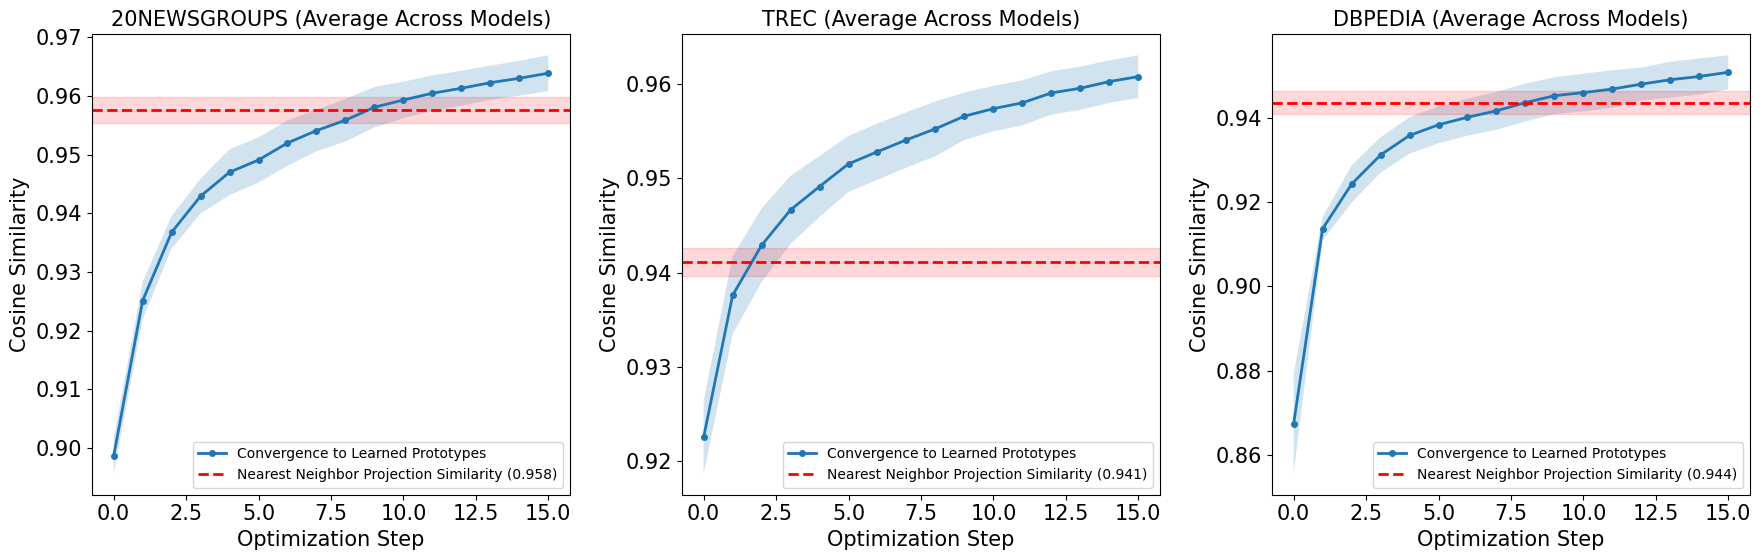


=== Creating all combinations plots (3x3) ===
Loaded data for seed 0
Loaded data for seed 1
Loaded data for seed 2
Loaded data for seed 3
Loaded data for seed 4
Available seeds: [0, 1, 2, 3, 4]

Processing 20newsgroups-bert...
  Seed 0: Found 20 prototypes
  Seed 1: Found 20 prototypes
  Seed 2: Found 20 prototypes
  No data for 20newsgroups-bert in seed 3
  Seed 4: Found 20 prototypes

Processing 20newsgroups-electra...
  Seed 0: Found 20 prototypes
  Seed 1: Found 20 prototypes
  No data for 20newsgroups-electra in seed 2
  Seed 3: Found 20 prototypes
  Seed 4: Found 20 prototypes

Processing 20newsgroups-roberta...
  Seed 0: Found 20 prototypes
  No data for 20newsgroups-roberta in seed 1
  Seed 2: Found 20 prototypes
  Seed 3: Found 20 prototypes
  Seed 4: Found 20 prototypes

Processing trec-bert...
  Seed 0: Found 47 prototypes
  Seed 1: Found 47 prototypes
  Seed 2: Found 47 prototypes
  Seed 3: Found 47 prototypes
  No data for trec-bert in seed 4

Processing trec-electra...
 

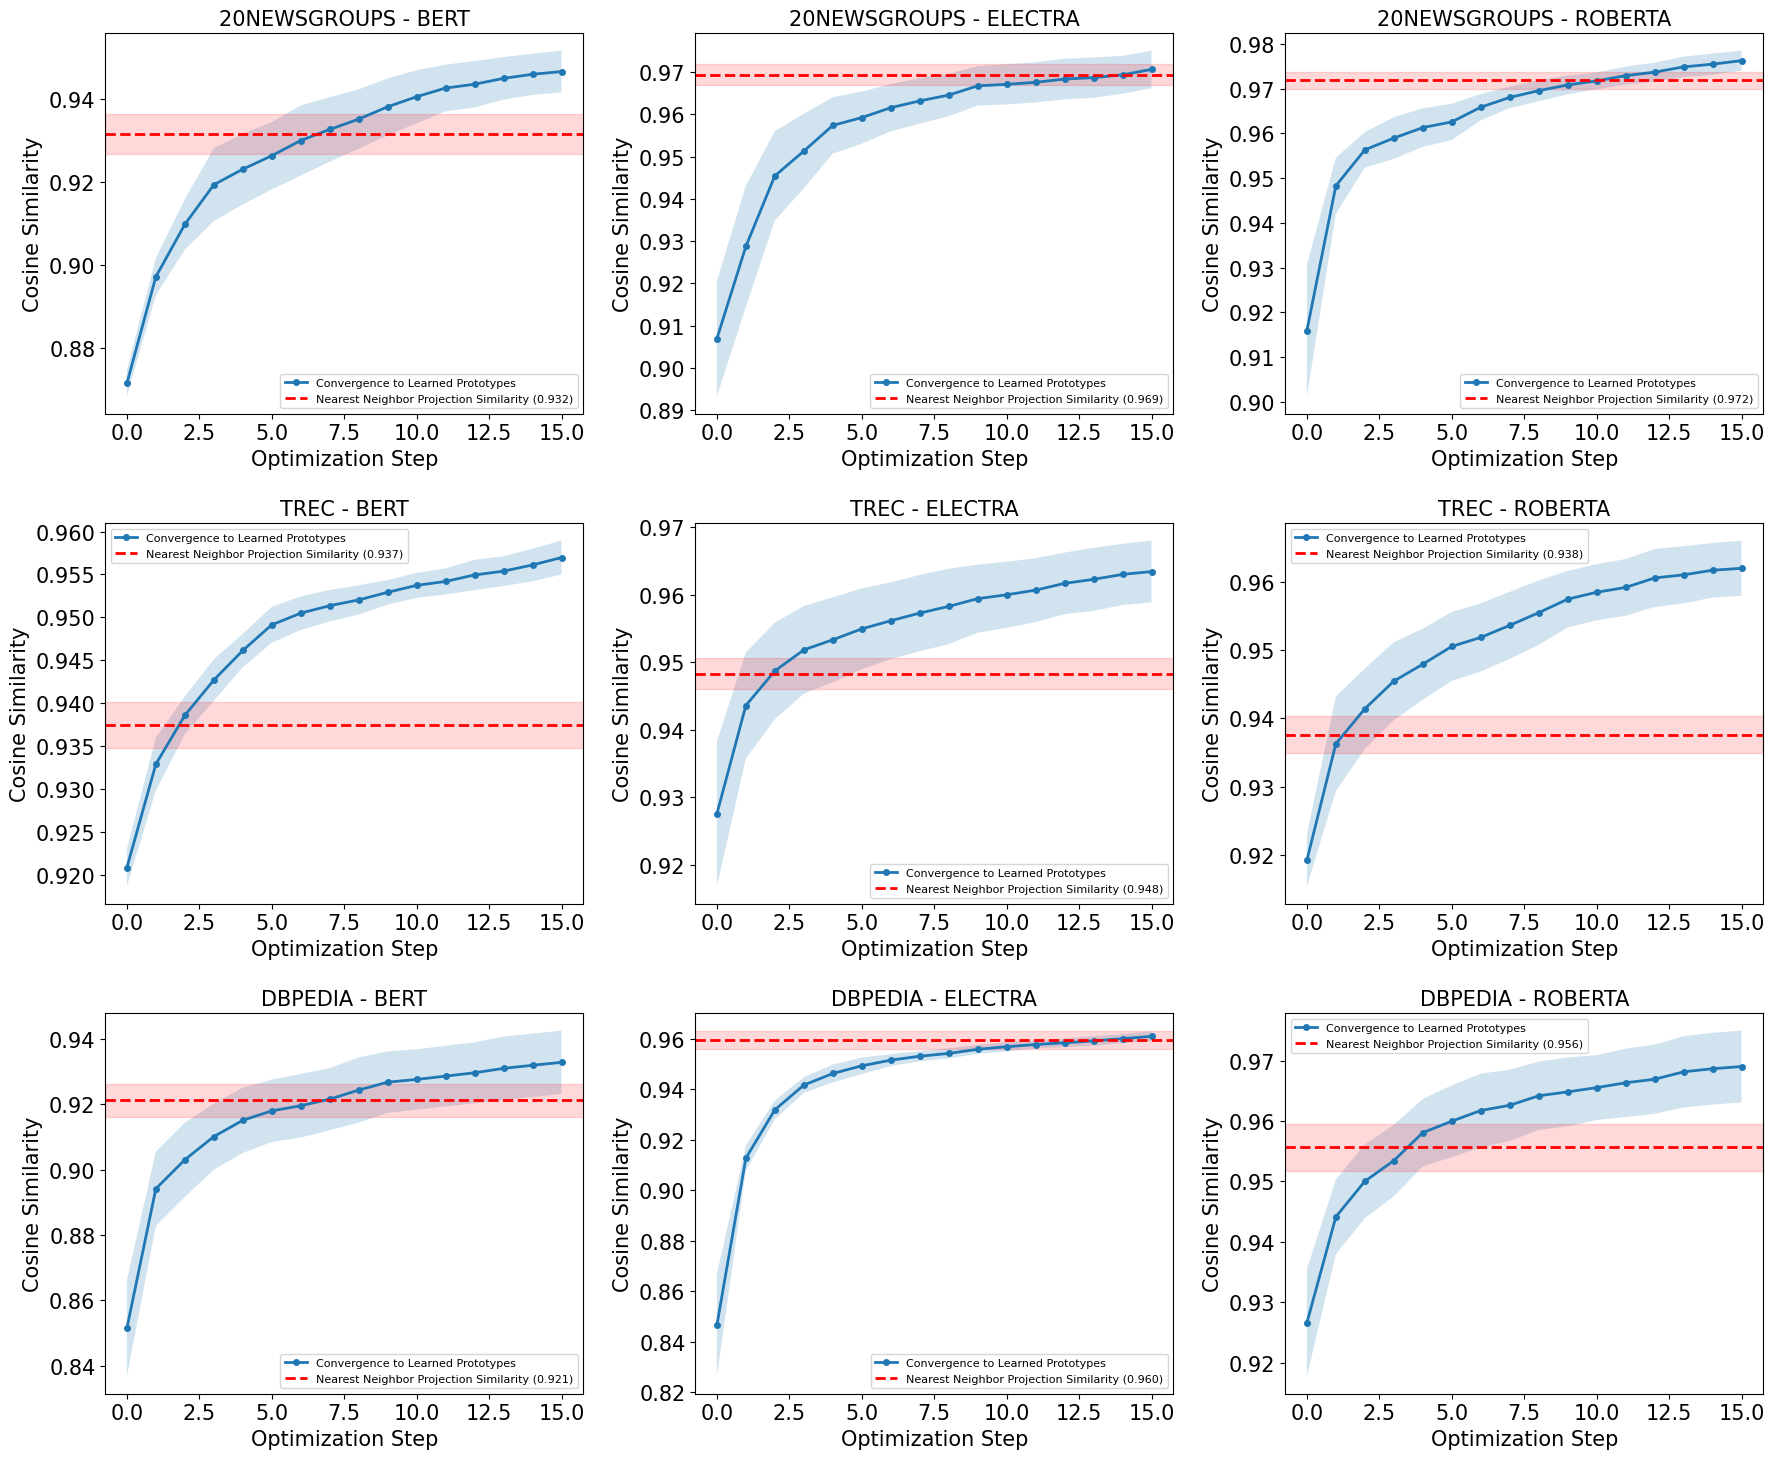

In [61]:
#!/usr/bin/env python3
"""
Multi-seed plotting script showing optimization convergence across multiple seeds.
Plots mean ± standard error across seeds for cosine similarities.
Y-axis scales dynamically per plot using standard error for zoomed-in view.
"""

import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

import matplotlib.pyplot as plt

# Make all fonts roughly double size
plt.rcParams.update({
    "font.size": 20,          # base font size
    "axes.titlesize": 15,     # subplot titles
    "axes.labelsize": 15,     # x and y labels
    "xtick.labelsize": 15,    # x tick labels
    "ytick.labelsize": 15,    # y tick labels
    "legend.fontsize": 10     # legend
})


seeds = [0,1,2,3,4]  # Modify this list as needed

def create_averaged_plots():
    """Create plots averaged across models (1x3 plot for each dataset)"""
    # Load data for all available seeds
    all_data_by_seed = {}
    available_seeds = []
    
    for seed in seeds:
        try:
            with open(f'data/optimization_exp_all_data_seed{seed}.pickle', 'rb') as handle:
                all_data_by_seed[seed] = pickle.load(handle)
                available_seeds.append(seed)
                print(f"Loaded data for seed {seed}")
        except FileNotFoundError:
            print(f"Warning: Data file for seed {seed} not found, skipping")
            continue
    
    if not all_data_by_seed:
        print("No data files found!")
        return
    
    print(f"Available seeds: {available_seeds}")
    
    datasets = ['20newsgroups', 'trec', 'dbpedia']
    models = ['bert', 'electra', 'roberta']
    
    # Create the 1x3 subplot (averaged across models)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    os.makedirs('plots', exist_ok=True)
    
    for i, dataset in enumerate(datasets):
        ax = axes[i]
        
        print(f"\nProcessing dataset {dataset} (averaging across models)...")
        
        # Collect data across all models and seeds for this dataset
        all_early_distances = []
        all_optimization_curves = []  # List of mean curves (one per seed-model combination)
        
        for seed in available_seeds:
            all_data = all_data_by_seed[seed]
            
            # Collect curves for this seed across all models
            seed_curves = []
            seed_early_distances = []
            
            for model in models:
                key = f'{dataset}_{model}_latent_optim_3llms'
                
                if key not in all_data or not all_data[key]:
                    print(f"  No data for {dataset}-{model} in seed {seed}")
                    continue
                
                experiment_data = all_data[key]
                print(f"  Seed {seed}, {model}: Found {len(experiment_data)} prototypes")
                
                # Extract data
                early_distances = [float(proto['early_distance']) for proto in experiment_data]
                histories = [list(map(float, proto['max_similarity'])) for proto in experiment_data]
                
                if not histories:
                    continue
                
                max_len = max(len(h) for h in histories)
                padded = [h + [h[-1]] * (max_len - len(h)) for h in histories]
                similarities_array = np.array(padded, dtype=float)
                mean_for_seed_model = np.mean(similarities_array, axis=0)
                
                seed_curves.append(mean_for_seed_model)
                seed_early_distances.extend(early_distances)
            
            if seed_curves:
                min_len = min(len(curve) for curve in seed_curves)
                truncated_curves = [curve[:min_len] for curve in seed_curves]
                seed_avg_curve = np.mean(truncated_curves, axis=0)
                
                all_optimization_curves.append(seed_avg_curve)
                all_early_distances.extend(seed_early_distances)
        
        if not all_optimization_curves:
            ax.text(0.5, 0.5, f'No data\n{dataset}', 
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{dataset.upper()}')
            ax.set_xlabel('Iteration')
            ax.set_ylabel('Cosine Similarity')
            continue
        
        # Find common length for curves
        min_len = min(len(curve) for curve in all_optimization_curves)
        truncated_curves = [curve[:min_len] for curve in all_optimization_curves]
        curves_array = np.array(truncated_curves)
        
        mean_across_seeds = np.mean(curves_array, axis=0)
        std_across_seeds = np.std(curves_array, axis=0, ddof=1) if len(curves_array) > 1 else np.zeros_like(mean_across_seeds)
        sem_across_seeds = std_across_seeds / np.sqrt(len(curves_array)) if len(curves_array) > 1 else np.zeros_like(mean_across_seeds)
        
        iterations = np.arange(min_len)
        
        # Early baseline
        early_mean = float(np.mean(all_early_distances))
        early_std = float(np.std(all_early_distances, ddof=1)) if len(all_early_distances) > 1 else 0.0
        early_sem = early_std / np.sqrt(len(all_early_distances)) if len(all_early_distances) > 1 else 0.0
        
        # Plot
        ax.plot(iterations, mean_across_seeds, linewidth=2, 
                label=f'Convergence to Learned Prototypes', marker='o', markersize=4)
        ax.fill_between(iterations, 
                        mean_across_seeds - sem_across_seeds,
                        mean_across_seeds + sem_across_seeds,
                        alpha=0.2)
        
        ax.axhline(y=early_mean, linestyle='--', linewidth=2, color='red',
                   label=f'Nearest Neighbor Projection Similarity ({early_mean:.3f})')
        ax.axhspan(early_mean - early_sem, early_mean + early_sem, 
                   alpha=0.15, color='red')
        
        ax.set_xlabel('Optimization Step')
        ax.set_ylabel('Cosine Similarity')
        ax.set_title(f'{dataset.upper()} (Average Across Models)')
        
        ax.legend(fontsize=10)
        ax.grid(False)

        ymin = min(np.min(mean_across_seeds - sem_across_seeds), early_mean - early_sem)
        ymax = max(np.max(mean_across_seeds + sem_across_seeds), early_mean + early_sem)
        pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
        ax.set_ylim(ymin - pad, ymax + pad)
    
    plt.tight_layout()
    
    plot_path = 'plots/convergence_analysis_multiseed_averaged_models.pdf'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nAveraged plot saved to: {plot_path}")
    plt.show()

def create_multi_seed_plots():
    """Create original 3x3 plots showing all dataset-model combinations"""
    all_data_by_seed = {}
    available_seeds = []
    
    for seed in seeds:
        try:
            with open(f'data/optimization_exp_all_data_seed{seed}.pickle', 'rb') as handle:
                all_data_by_seed[seed] = pickle.load(handle)
                available_seeds.append(seed)
                print(f"Loaded data for seed {seed}")
        except FileNotFoundError:
            print(f"Warning: Data file for seed {seed} not found, skipping")
            continue
    
    if not all_data_by_seed:
        print("No data files found!")
        return
    
    print(f"Available seeds: {available_seeds}")
    
    datasets = ['20newsgroups', 'trec', 'dbpedia']
    models = ['bert', 'electra', 'roberta']
    
    # Create the 3x3 subplot
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    
    os.makedirs('plots', exist_ok=True)
    
    for i, dataset in enumerate(datasets):
        for j, model in enumerate(models):
            ax = axes[i, j]
            
            print(f"\nProcessing {dataset}-{model}...")
            
            all_early_distances = []
            all_optimization_curves = []
            
            for seed in available_seeds:
                key = f'{dataset}_{model}_latent_optim_3llms'
                all_data = all_data_by_seed[seed]
                
                if key not in all_data or not all_data[key]:
                    print(f"  No data for {dataset}-{model} in seed {seed}")
                    continue
                
                experiment_data = all_data[key]
                print(f"  Seed {seed}: Found {len(experiment_data)} prototypes")
                
                early_distances = [float(proto['early_distance']) for proto in experiment_data]
                histories = [list(map(float, proto['max_similarity'])) for proto in experiment_data]
                
                if not histories:
                    continue
                
                max_len = max(len(h) for h in histories)
                padded = [h + [h[-1]] * (max_len - len(h)) for h in histories]
                similarities_array = np.array(padded, dtype=float)
                mean_for_seed = np.mean(similarities_array, axis=0)
                
                all_early_distances.extend(early_distances)
                all_optimization_curves.append(mean_for_seed)
            
            if not all_optimization_curves:
                ax.text(0.5, 0.5, f'No data\n{dataset}-{model}', 
                        ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{dataset.upper()} - {model.upper()}')
                ax.set_xlabel('Optimization Step')
                ax.set_ylabel('Cosine Similarity')
                continue
            
            min_len = min(len(curve) for curve in all_optimization_curves)
            truncated_curves = [curve[:min_len] for curve in all_optimization_curves]
            curves_array = np.array(truncated_curves)
            
            mean_across_seeds = np.mean(curves_array, axis=0)
            std_across_seeds = np.std(curves_array, axis=0, ddof=1) if len(curves_array) > 1 else np.zeros_like(mean_across_seeds)
            sem_across_seeds = std_across_seeds / np.sqrt(len(curves_array)) if len(curves_array) > 1 else np.zeros_like(mean_across_seeds)
            
            iterations = np.arange(min_len)
            
            early_mean = float(np.mean(all_early_distances))
            early_std = float(np.std(all_early_distances, ddof=1)) if len(all_early_distances) > 1 else 0.0
            early_sem = early_std / np.sqrt(len(all_early_distances)) if len(all_early_distances) > 1 else 0.0
            
            ax.plot(iterations, mean_across_seeds, linewidth=2, 
                    label=f'Convergence to Learned Prototypes', marker='o', markersize=4)
            ax.fill_between(iterations, 
                            mean_across_seeds - sem_across_seeds,
                            mean_across_seeds + sem_across_seeds,
                            alpha=0.2)
            
            ax.axhline(y=early_mean, linestyle='--', linewidth=2, color='red',
                       label=f'Nearest Neighbor Projection Similarity ({early_mean:.3f})')
            ax.axhspan(early_mean - early_sem, early_mean + early_sem, 
                       alpha=0.15, color='red')
            
            ax.set_xlabel('Optimization Step')
            ax.set_ylabel('Cosine Similarity')
            ax.set_title(f'{dataset.upper()} - {model.upper()}')
            
            ax.legend(fontsize=8)
            ax.grid(False)

            ymin = min(np.min(mean_across_seeds - sem_across_seeds), early_mean - early_sem)
            ymax = max(np.max(mean_across_seeds + sem_across_seeds), early_mean + early_sem)
            pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
            ax.set_ylim(ymin - pad, ymax + pad)
    
    plt.tight_layout()
    
    plot_path = 'plots/convergence_analysis_multiseed_all_combinations.pdf'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nAll combinations plot saved to: {plot_path}")
    plt.show()

if __name__ == "__main__":
    print(f"Creating multi-seed convergence plots for seeds: {seeds}")
    
    print("\n=== Creating averaged plots (across datasets) ===")
    create_averaged_plots()
    
    print("\n=== Creating all combinations plots (3x3) ===")
    create_multi_seed_plots()


In [65]:
#!/usr/bin/env python3
"""
Extract and display summary results from the experiment data in table format.
Shows accuracy metrics, precision, recall, F1 scores, and cosine similarity measurements across multiple seeds.
Reports mean ± standard error for each metric.
Includes statistical significance testing between Stage A and Stage B results.
"""

import pickle
import pandas as pd
import numpy as np
from scipy import stats

seeds = [0,1,2,3,4]  # Modify this list as needed

def extract_summary_data():
    # Load data for all available seeds
    all_data_by_seed = {}
    for seed in seeds:
        try:
            with open(f'data/accuracy_run_optimize/optimization_exp_all_data_seed{seed}.pickle', 'rb') as handle:
                all_data_by_seed[seed] = pickle.load(handle)
                print(f"Loaded data for seed {seed}")
        except FileNotFoundError:
            print(f"Warning: Data file for seed {seed} not found, skipping")
            continue
    
    if not all_data_by_seed:
        print("No data files found!")
        return []
    
    datasets = ['trec', 'dbpedia', '20newsgroups']
    models = ['bert', 'electra', 'roberta']
    
    results = []
    
    for dataset in datasets:
        for model in models:
            # Collect metrics across all available seeds for this dataset/model combination
            metrics_across_seeds = {
                'base_acc': [],
                'stageA_acc': [],
                'stageB_acc': [],
                'base_f1': [],
                'stageA_f1': [],
                'stageB_f1': [],
                'base_precision': [],
                'stageA_precision': [],
                'stageB_precision': [],
                'base_recall': [],
                'stageA_recall': [],
                'stageB_recall': [],
                'cos_proto_to_train': [],
                'cos_optimized_to_proto': []
            }
            
            for seed in seeds:
                if seed not in all_data_by_seed:
                    continue
                
                all_data = all_data_by_seed[seed]
                summary_key = f'{dataset}_{model}_latent_optim_3llms_summary'
                
                if summary_key in all_data:
                    summary = all_data[summary_key]
                    
                    # Extract accuracy metrics
                    base_acc = summary.get('base_metrics', {}).get('accuracy', None)
                    if base_acc is not None:
                        metrics_across_seeds['base_acc'].append(base_acc)
                    
                    stageA_acc = summary.get('stageA_metrics_optimized_text_latents', {}).get('accuracy', None)
                    if stageA_acc is not None:
                        metrics_across_seeds['stageA_acc'].append(stageA_acc)
                    
                    stageB_acc = summary.get('stageB_metrics_projected', {}).get('accuracy', None)
                    if stageB_acc is not None:
                        metrics_across_seeds['stageB_acc'].append(stageB_acc)
                    
                    # Extract F1 scores
                    base_f1 = summary.get('base_metrics', {}).get('macro', {}).get('f1', None)
                    if base_f1 is not None:
                        metrics_across_seeds['base_f1'].append(base_f1)
                    
                    stageA_f1 = summary.get('stageA_metrics_optimized_text_latents', {}).get('macro', {}).get('f1', None)
                    if stageA_f1 is not None:
                        metrics_across_seeds['stageA_f1'].append(stageA_f1)
                    
                    stageB_f1 = summary.get('stageB_metrics_projected', {}).get('macro', {}).get('f1', None)
                    if stageB_f1 is not None:
                        metrics_across_seeds['stageB_f1'].append(stageB_f1)
                    
                    # Extract precision scores
                    base_precision = summary.get('base_metrics', {}).get('macro', {}).get('precision', None)
                    if base_precision is not None:
                        metrics_across_seeds['base_precision'].append(base_precision)
                    
                    stageA_precision = summary.get('stageA_metrics_optimized_text_latents', {}).get('macro', {}).get('precision', None)
                    if stageA_precision is not None:
                        metrics_across_seeds['stageA_precision'].append(stageA_precision)
                    
                    stageB_precision = summary.get('stageB_metrics_projected', {}).get('macro', {}).get('precision', None)
                    if stageB_precision is not None:
                        metrics_across_seeds['stageB_precision'].append(stageB_precision)
                    
                    # Extract recall scores
                    base_recall = summary.get('base_metrics', {}).get('macro', {}).get('recall', None)
                    if base_recall is not None:
                        metrics_across_seeds['base_recall'].append(base_recall)
                    
                    stageA_recall = summary.get('stageA_metrics_optimized_text_latents', {}).get('macro', {}).get('recall', None)
                    if stageA_recall is not None:
                        metrics_across_seeds['stageA_recall'].append(stageA_recall)
                    
                    stageB_recall = summary.get('stageB_metrics_projected', {}).get('macro', {}).get('recall', None)
                    if stageB_recall is not None:
                        metrics_across_seeds['stageB_recall'].append(stageB_recall)
                    
                    # Extract cosine similarity metrics
                    cos_proto_to_train = summary.get('avg_cosine_proto_to_nearest_train', None)
                    if cos_proto_to_train is not None:
                        metrics_across_seeds['cos_proto_to_train'].append(cos_proto_to_train)
                    
                    cos_optimized_to_proto = summary.get('avg_cosine_optimized_to_proto', None)
                    if cos_optimized_to_proto is not None:
                        metrics_across_seeds['cos_optimized_to_proto'].append(cos_optimized_to_proto)
                else:
                    print(f"Warning: Summary key '{summary_key}' not found for seed {seed}")
            
            # Compute mean and standard error for each metric
            def compute_stats(values):
                if len(values) == 0:
                    return None, None, 0
                elif len(values) == 1:
                    return values[0], 0.0, 1
                else:
                    mean = np.mean(values)
                    std_err = np.std(values, ddof=1) / np.sqrt(len(values))
                    return mean, std_err, len(values)
            
            # Apply to all metrics
            base_acc_mean, base_acc_se, base_acc_n = compute_stats(metrics_across_seeds['base_acc'])
            stageA_acc_mean, stageA_acc_se, stageA_acc_n = compute_stats(metrics_across_seeds['stageA_acc'])
            stageB_acc_mean, stageB_acc_se, stageB_acc_n = compute_stats(metrics_across_seeds['stageB_acc'])
            
            base_f1_mean, base_f1_se, base_f1_n = compute_stats(metrics_across_seeds['base_f1'])
            stageA_f1_mean, stageA_f1_se, stageA_f1_n = compute_stats(metrics_across_seeds['stageA_f1'])
            stageB_f1_mean, stageB_f1_se, stageB_f1_n = compute_stats(metrics_across_seeds['stageB_f1'])
            
            base_precision_mean, base_precision_se, base_precision_n = compute_stats(metrics_across_seeds['base_precision'])
            stageA_precision_mean, stageA_precision_se, stageA_precision_n = compute_stats(metrics_across_seeds['stageA_precision'])
            stageB_precision_mean, stageB_precision_se, stageB_precision_n = compute_stats(metrics_across_seeds['stageB_precision'])
            
            base_recall_mean, base_recall_se, base_recall_n = compute_stats(metrics_across_seeds['base_recall'])
            stageA_recall_mean, stageA_recall_se, stageA_recall_n = compute_stats(metrics_across_seeds['stageA_recall'])
            stageB_recall_mean, stageB_recall_se, stageB_recall_n = compute_stats(metrics_across_seeds['stageB_recall'])
            
            cos_proto_mean, cos_proto_se, cos_proto_n = compute_stats(metrics_across_seeds['cos_proto_to_train'])
            cos_opt_mean, cos_opt_se, cos_opt_n = compute_stats(metrics_across_seeds['cos_optimized_to_proto'])
            
            # Statistical significance test between Stage A and Stage B accuracies
            pvalue_acc_A_vs_B = None
            if (len(metrics_across_seeds['stageA_acc']) >= 2 and 
                len(metrics_across_seeds['stageB_acc']) >= 2 and
                len(metrics_across_seeds['stageA_acc']) == len(metrics_across_seeds['stageB_acc'])):
                try:
                    # Paired t-test between Stage A and Stage B accuracies
                    stat, p_val = stats.ttest_rel(metrics_across_seeds['stageA_acc'], 
                                                  metrics_across_seeds['stageB_acc'])
                    pvalue_acc_A_vs_B = p_val
                except:
                    pvalue_acc_A_vs_B = None
            
            results.append({
                'Dataset': dataset.upper(),
                'Model': model.upper(),
                'Base_Acc_Mean': base_acc_mean,
                'Base_Acc_SE': base_acc_se,
                'Base_Acc_N': base_acc_n,
                'StageA_Acc_Mean': stageA_acc_mean,
                'StageA_Acc_SE': stageA_acc_se,
                'StageA_Acc_N': stageA_acc_n,
                'StageB_Acc_Mean': stageB_acc_mean,
                'StageB_Acc_SE': stageB_acc_se,
                'StageB_Acc_N': stageB_acc_n,
                'PValue_A_vs_B_Acc': pvalue_acc_A_vs_B,
                'Base_F1_Mean': base_f1_mean,
                'Base_F1_SE': base_f1_se,
                'StageA_F1_Mean': stageA_f1_mean,
                'StageA_F1_SE': stageA_f1_se,
                'StageB_F1_Mean': stageB_f1_mean,
                'StageB_F1_SE': stageB_f1_se,
                'Base_Precision_Mean': base_precision_mean,
                'Base_Precision_SE': base_precision_se,
                'StageA_Precision_Mean': stageA_precision_mean,
                'StageA_Precision_SE': stageA_precision_se,
                'StageB_Precision_Mean': stageB_precision_mean,
                'StageB_Precision_SE': stageB_precision_se,
                'Base_Recall_Mean': base_recall_mean,
                'Base_Recall_SE': base_recall_se,
                'StageA_Recall_Mean': stageA_recall_mean,
                'StageA_Recall_SE': stageA_recall_se,
                'StageB_Recall_Mean': stageB_recall_mean,
                'StageB_Recall_SE': stageB_recall_se,
                'Cos_Proto_Mean': cos_proto_mean,
                'Cos_Proto_SE': cos_proto_se,
                'Cos_Opt_Mean': cos_opt_mean,
                'Cos_Opt_SE': cos_opt_se,
            })
    
    return results

def format_mean_se(mean, se, n):
    """Format mean ± standard error with sample size"""
    if mean is None:
        return "N/A"
    elif se is None or se == 0:
        return f"{mean:.4f} (n={n})"
    else:
        return f"{mean:.4f}±{se:.4f} (n={n})"

def format_pvalue(pvalue):
    """Format p-value with appropriate precision"""
    if pvalue is None:
        return "N/A"
    elif pvalue < 0.001:
        return "<0.001"
    else:
        return f"{pvalue:.3f}"

def display_results_table(results):
    df = pd.DataFrame(results)
    
    print("="*160)
    print("EXPERIMENT RESULTS SUMMARY (Mean ± Standard Error)")
    print("="*160)
    
    print("\nACCURACY RESULTS")
    print("-" * 140)
    print(f"{'Dataset':<12} {'Model':<8} {'Base':<20} {'Stage A':<20} {'Stage B':<20} {'p-value (A vs B)':<15}")
    print("-" * 140)
    
    for _, row in df.iterrows():
        base_acc = format_mean_se(row['Base_Acc_Mean'], row['Base_Acc_SE'], row['Base_Acc_N'])
        stageA_acc = format_mean_se(row['StageA_Acc_Mean'], row['StageA_Acc_SE'], row['StageA_Acc_N'])
        stageB_acc = format_mean_se(row['StageB_Acc_Mean'], row['StageB_Acc_SE'], row['StageB_Acc_N'])
        pvalue = format_pvalue(row['PValue_A_vs_B_Acc'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {base_acc:<20} {stageA_acc:<20} {stageB_acc:<20} {pvalue:<15}")
    
    print("\nMACRO F1 SCORES")
    print("-" * 100)
    print(f"{'Dataset':<12} {'Model':<8} {'Base':<20} {'Stage A':<20} {'Stage B':<20}")
    print("-" * 100)
    
    for _, row in df.iterrows():
        base_f1 = format_mean_se(row['Base_F1_Mean'], row['Base_F1_SE'], row['Base_Acc_N'])
        stageA_f1 = format_mean_se(row['StageA_F1_Mean'], row['StageA_F1_SE'], row['StageA_Acc_N'])
        stageB_f1 = format_mean_se(row['StageB_F1_Mean'], row['StageB_F1_SE'], row['StageB_Acc_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {base_f1:<20} {stageA_f1:<20} {stageB_f1:<20}")
    
    print("\nMACRO PRECISION SCORES")
    print("-" * 100)
    print(f"{'Dataset':<12} {'Model':<8} {'Base':<20} {'Stage A':<20} {'Stage B':<20}")
    print("-" * 100)
    
    for _, row in df.iterrows():
        base_precision = format_mean_se(row['Base_Precision_Mean'], row['Base_Precision_SE'], row['Base_Acc_N'])
        stageA_precision = format_mean_se(row['StageA_Precision_Mean'], row['StageA_Precision_SE'], row['StageA_Acc_N'])
        stageB_precision = format_mean_se(row['StageB_Precision_Mean'], row['StageB_Precision_SE'], row['StageB_Acc_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {base_precision:<20} {stageA_precision:<20} {stageB_precision:<20}")
    
    print("\nMACRO RECALL SCORES")
    print("-" * 100)
    print(f"{'Dataset':<12} {'Model':<8} {'Base':<20} {'Stage A':<20} {'Stage B':<20}")
    print("-" * 100)
    
    for _, row in df.iterrows():
        base_recall = format_mean_se(row['Base_Recall_Mean'], row['Base_Recall_SE'], row['Base_Acc_N'])
        stageA_recall = format_mean_se(row['StageA_Recall_Mean'], row['StageA_Recall_SE'], row['StageA_Acc_N'])
        stageB_recall = format_mean_se(row['StageB_Recall_Mean'], row['StageB_Recall_SE'], row['StageB_Acc_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {base_recall:<20} {stageA_recall:<20} {stageB_recall:<20}")
    
    print("\nCOSINE SIMILARITY TO BLACK BOX PROTOTYPES")
    print("-" * 90)
    print(f"{'Dataset':<12} {'Model':<8} {'Proto->Train':<25} {'Opt->Proto':<25}")
    print("-" * 90)
    
    for _, row in df.iterrows():
        cos1 = format_mean_se(row['Cos_Proto_Mean'], row['Cos_Proto_SE'], row['Base_Acc_N'])
        cos2 = format_mean_se(row['Cos_Opt_Mean'], row['Cos_Opt_SE'], row['Base_Acc_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<8} {cos1:<25} {cos2:<25}")
    
    # Summary statistics
    print("\nSUMMARY STATISTICS")
    print("-" * 50)
    
    # Count significant differences (p < 0.05)
    valid_pvalues = [row['PValue_A_vs_B_Acc'] for _, row in df.iterrows() 
                     if row['PValue_A_vs_B_Acc'] is not None]
    significant_diffs = sum(1 for p in valid_pvalues if p < 0.05)
    
    print(f"Significant differences (p<0.05) between Stage A and B: {significant_diffs}/{len(valid_pvalues)} combinations")
    
    # Count how many times Stage A > Stage B for each metric (based on mean values)
    print(f"\nStage A vs Stage B Performance (based on mean values):")
    print("-" * 50)
    
    metrics_comparison = {
        'Accuracy': ('StageA_Acc_Mean', 'StageB_Acc_Mean'),
        'F1 Score': ('StageA_F1_Mean', 'StageB_F1_Mean'),
        'Precision': ('StageA_Precision_Mean', 'StageB_Precision_Mean'),
        'Recall': ('StageA_Recall_Mean', 'StageB_Recall_Mean')
    }
    
    for metric_name, (stageA_col, stageB_col) in metrics_comparison.items():
        # Count valid comparisons
        valid_comparisons = []
        for _, row in df.iterrows():
            if row[stageA_col] is not None and row[stageB_col] is not None:
                valid_comparisons.append((row[stageA_col], row[stageB_col]))
        
        if valid_comparisons:
            stage_a_wins = sum(1 for a, b in valid_comparisons if a > b)
            stage_b_wins = sum(1 for a, b in valid_comparisons if b > a)
            ties = sum(1 for a, b in valid_comparisons if a == b)
            total = len(valid_comparisons)
            
            print(f"{metric_name:<12}: Stage A wins: {stage_a_wins}/{total}, Stage B wins: {stage_b_wins}/{total}, Ties: {ties}/{total}")
    
    # Show combinations with significant differences
    if significant_diffs > 0:
        print(f"\nSignificant differences found in:")
        for _, row in df.iterrows():
            if row['PValue_A_vs_B_Acc'] is not None and row['PValue_A_vs_B_Acc'] < 0.05:
                direction = "A > B" if row['StageA_Acc_Mean'] > row['StageB_Acc_Mean'] else "B > A"
                print(f"  {row['Dataset']}-{row['Model']}: p={row['PValue_A_vs_B_Acc']:.4f} ({direction})")
    
    return df

def save_results_table(df):
    # Save as CSV for easy analysis
    df.to_csv('plots/experiment_results_summary_multiseed.csv', index=False)
    print(f"\nResults saved to: plots/experiment_results_summary_multiseed.csv")
    
    # Create a formatted text report
    with open('plots/experiment_results_report_multiseed.txt', 'w') as f:
        f.write("EXPERIMENT RESULTS SUMMARY (Multi-seed)\n")
        f.write("="*50 + "\n\n")
        
        f.write("ACCURACY RESULTS (Mean ± SE):\n")
        f.write("-"*40 + "\n")
        
        for _, row in df.iterrows():
            if row['Base_Acc_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<8} "
                       f"Base: {row['Base_Acc_Mean']:.4f}±{row['Base_Acc_SE']:.4f}, "
                       f"A: {row['StageA_Acc_Mean']:.4f}±{row['StageA_Acc_SE']:.4f}, "
                       f"B: {row['StageB_Acc_Mean']:.4f}±{row['StageB_Acc_SE']:.4f}")
                if row['PValue_A_vs_B_Acc'] is not None:
                    f.write(f", p(A vs B): {row['PValue_A_vs_B_Acc']:.4f}")
                f.write("\n")
        
        f.write(f"\nPRECISION & RECALL (Mean ± SE):\n")
        f.write("-"*40 + "\n")
        
        for _, row in df.iterrows():
            if row['Base_Precision_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<8} Precision - "
                       f"Base: {row['Base_Precision_Mean']:.4f}±{row['Base_Precision_SE']:.4f}, "
                       f"A: {row['StageA_Precision_Mean']:.4f}±{row['StageA_Precision_SE']:.4f}, "
                       f"B: {row['StageB_Precision_Mean']:.4f}±{row['StageB_Precision_SE']:.4f}\n")
            if row['Base_Recall_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<8} Recall - "
                       f"Base: {row['Base_Recall_Mean']:.4f}±{row['Base_Recall_SE']:.4f}, "
                       f"A: {row['StageA_Recall_Mean']:.4f}±{row['StageA_Recall_SE']:.4f}, "
                       f"B: {row['StageB_Recall_Mean']:.4f}±{row['StageB_Recall_SE']:.4f}\n")
        
        f.write(f"\nCOSINE SIMILARITIES (Mean ± SE):\n")
        f.write("-"*40 + "\n")
        
        for _, row in df.iterrows():
            if row['Cos_Proto_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<8} "
                       f"Proto->Train: {row['Cos_Proto_Mean']:.4f}±{row['Cos_Proto_SE']:.4f}, "
                       f"Opt->Proto: {row['Cos_Opt_Mean']:.4f}±{row['Cos_Opt_SE']:.4f}\n")
    
    print(f"Text report saved to: plots/experiment_results_report_multiseed.txt")

def main():
    print(f"Extracting summary data from experiment results across seeds: {seeds}")
    
    results = extract_summary_data()
    
    if not results:
        print("No summary data found!")
        return
    
    print(f"Found summary data for {len(results)} dataset/model combinations\n")
    
    df = display_results_table(results)
    save_results_table(df)
    
    print("\n" + "="*160)
    print("Legend:")
    print("• Base: Original network accuracy/precision/recall/F1")
    print("• Stage A: After optimizing prototypes with text (pre-projection)")
    print("• Stage B: After projecting to nearest training embeddings (post-projection)")
    print("• p-value (A vs B): Paired t-test p-value comparing Stage A vs Stage B accuracies")
    print("• Proto->Train: Cosine similarity between learned prototypes and nearest training embeddings")
    print("• Opt->Proto: Cosine similarity between optimized text prototypes and original learned prototypes")
    print("• Format: Mean±SE (n=sample_size)")
    print(f"• Seeds analyzed: {seeds}")
    print("• Significance level: p < 0.05")

if __name__ == "__main__":
    main()

Extracting summary data from experiment results across seeds: [0, 1, 2, 3, 4]
Loaded data for seed 0
Loaded data for seed 1
Loaded data for seed 2
Loaded data for seed 3
Loaded data for seed 4
Found summary data for 9 dataset/model combinations

EXPERIMENT RESULTS SUMMARY (Mean ± Standard Error)

ACCURACY RESULTS
--------------------------------------------------------------------------------------------------------------------------------------------
Dataset      Model    Base                 Stage A              Stage B              p-value (A vs B)
--------------------------------------------------------------------------------------------------------------------------------------------
TREC         BERT     0.8665±0.0052 (n=4)  0.8545±0.0063 (n=4)  0.8475±0.0050 (n=4)  0.094          
TREC         ELECTRA  0.8305±0.0064 (n=4)  0.8265±0.0066 (n=4)  0.8240±0.0054 (n=4)  0.194          
TREC         ROBERTA  0.8480±0.0071 (n=4)  0.8465±0.0095 (n=4)  0.8390±0.0105 (n=4)  0.087         

In [50]:
#!/usr/bin/env python3
"""
Verify the summary metrics by manually calculating them from individual prototype data.
"""

import pickle
import numpy as np

def verify_summary_metrics():
    # Load data
    with open('data/ground_truth_exp_all_data_seed0.pickle', 'rb') as handle:
        all_data = pickle.load(handle)
    
    datasets = ['trec', 'dbpedia', '20newsgroups']
    models = ['bert', 'electra', 'roberta']
    
    print("VERIFYING SUMMARY METRICS")
    print("="*80)
    
    for dataset in datasets:
        for model in models:
            key = f'{dataset}_{model}_latent_optim_3llms'
            summary_key = f'{dataset}_{model}_latent_optim_3llms_summary'
            
            if key not in all_data or summary_key not in all_data:
                print(f"Missing data for {dataset}-{model}")
                continue
            
            experiment_data = all_data[key]
            summary_data = all_data[summary_key]
            
            print(f"\n{dataset.upper()}-{model.upper()}")
            print("-" * 40)
            
            # Extract individual prototype metrics
            early_distances = []
            final_max_similarities = []
            
            for proto_data in experiment_data:
                # Early distance (NN training similarity)
                early_dist = proto_data.get('early_distance')
                if early_dist is not None:
                    early_distances.append(early_dist)
                
                # Final max similarity (last value in max_similarity list)
                max_sim_list = proto_data.get('max_similarity', [])
                if max_sim_list:
                    final_max_similarities.append(max_sim_list[-1])
            
            # Calculate manual averages
            manual_avg_early = np.mean(early_distances) if early_distances else None
            manual_avg_final_max = np.mean(final_max_similarities) if final_max_similarities else None
            
            # Get summary metrics
            summary_proto_to_train = summary_data.get('avg_cosine_proto_to_nearest_train')
            summary_optimized_to_proto = summary_data.get('avg_cosine_optimized_to_proto')
            
            print(f"Number of prototypes: {len(early_distances)}")
            print()
            
            # Compare early distances vs proto_to_nearest_train
            print("EARLY DISTANCE (NN Training Similarity):")
            print(f"  Manual calculation: {manual_avg_early:.6f}")
            print(f"  Summary metric:     {summary_proto_to_train:.6f}")
            if manual_avg_early and summary_proto_to_train:
                diff1 = abs(manual_avg_early - summary_proto_to_train)
                print(f"  Difference:         {diff1:.6f}")
                match1 = diff1 < 1e-5
                print(f"  Match: {'✓' if match1 else '✗'}")
            print()
            
            # Compare final max similarities vs optimized_to_proto
            print("FINAL MAX SIMILARITY (Optimized vs Proto):")
            print(f"  Manual calculation: {manual_avg_final_max:.6f}")
            print(f"  Summary metric:     {summary_optimized_to_proto:.6f}")
            if manual_avg_final_max and summary_optimized_to_proto:
                diff2 = abs(manual_avg_final_max - summary_optimized_to_proto)
                print(f"  Difference:         {diff2:.6f}")
                match2 = diff2 < 1e-5
                print(f"  Match: {'✓' if match2 else '✗'}")
            
            # Show some individual values for debugging
            print()
            print("First 5 prototype values:")
            for i in range(min(5, len(early_distances))):
                early = early_distances[i]
                final_max = final_max_similarities[i] if i < len(final_max_similarities) else "N/A"
                print(f"  Proto {i}: early={early:.6f}, final_max={final_max}")

def detailed_verification():
    """More detailed verification with step-by-step calculation"""
    
    with open('data/ground_truth_exp_all_data_seed0.pickle', 'rb') as handle:
        all_data = pickle.load(handle)
    
    # Test with trec_bert first
    key = 'trec_bert_latent_optim_3llms'
    summary_key = 'trec_bert_latent_optim_3llms_summary'
    
    if key not in all_data:
        print("Test key not found")
        return
    
    experiment_data = all_data[key]
    summary_data = all_data[summary_key]
    
    print("\nDETAILED VERIFICATION - TREC BERT")
    print("="*50)
    
    print(f"Total prototypes: {len(experiment_data)}")
    
    # Collect all values
    all_early = []
    all_final_max = []
    all_avg_final = []  # final value from avg_similarity
    
    for i, proto in enumerate(experiment_data):
        early = proto.get('early_distance')
        max_sim = proto.get('max_similarity', [])
        avg_sim = proto.get('avg_similarity', [])
        
        if early is not None:
            all_early.append(early)
        
        if max_sim:
            all_final_max.append(max_sim[-1])
        
        if avg_sim:
            all_avg_final.append(avg_sim[-1])
        
        # Show first few for inspection
        if i < 3:
            print(f"\nPrototype {i}:")
            print(f"  early_distance: {early}")
            print(f"  max_similarity[-1]: {max_sim[-1] if max_sim else 'N/A'}")
            print(f"  avg_similarity[-1]: {avg_sim[-1] if avg_sim else 'N/A'}")
    
    # Calculate manual averages
    avg_early = np.mean(all_early)
    avg_final_max = np.mean(all_final_max)
    avg_final_avg = np.mean(all_avg_final)
    
    print(f"\nMANUAL CALCULATIONS:")
    print(f"  Avg early_distance:      {avg_early:.6f}")
    print(f"  Avg final max_similarity: {avg_final_max:.6f}")
    print(f"  Avg final avg_similarity: {avg_final_avg:.6f}")
    
    print(f"\nSUMMARY VALUES:")
    print(f"  avg_cosine_proto_to_nearest_train: {summary_data.get('avg_cosine_proto_to_nearest_train'):.6f}")
    print(f"  avg_cosine_optimized_to_proto:     {summary_data.get('avg_cosine_optimized_to_proto'):.6f}")
    
    print(f"\nCOMPARISONS:")
    print(f"  early_distance vs proto_to_nearest_train:")
    print(f"    Difference: {abs(avg_early - summary_data.get('avg_cosine_proto_to_nearest_train', 0)):.6f}")
    
    print(f"  final_max vs optimized_to_proto:")
    print(f"    Difference: {abs(avg_final_max - summary_data.get('avg_cosine_optimized_to_proto', 0)):.6f}")
    
    print(f"  final_avg vs optimized_to_proto:")
    print(f"    Difference: {abs(avg_final_avg - summary_data.get('avg_cosine_optimized_to_proto', 0)):.6f}")

if __name__ == "__main__":
    verify_summary_metrics()
    detailed_verification()

VERIFYING SUMMARY METRICS

TREC-BERT
----------------------------------------
Number of prototypes: 47

EARLY DISTANCE (NN Training Similarity):
  Manual calculation: 0.929921
  Summary metric:     0.859843
  Difference:         0.070079
  Match: ✗

FINAL MAX SIMILARITY (Optimized vs Proto):
  Manual calculation: 0.954866
  Summary metric:     0.909732
  Difference:         0.045134
  Match: ✗

First 5 prototype values:
  Proto 0: early=0.950737, final_max=0.9734785556793213
  Proto 1: early=0.933568, final_max=0.9830772876739502
  Proto 2: early=0.979425, final_max=0.985659122467041
  Proto 3: early=0.933156, final_max=0.965956449508667
  Proto 4: early=0.872681, final_max=0.9415208101272583

TREC-ELECTRA
----------------------------------------
Number of prototypes: 47

EARLY DISTANCE (NN Training Similarity):
  Manual calculation: 0.936622
  Summary metric:     0.873243
  Difference:         0.063379
  Match: ✗

FINAL MAX SIMILARITY (Optimized vs Proto):
  Manual calculation: 0.9565

## Compare Prototypes Visually for Qualitative Evaluation

Loaded data from data/optimization_exp_all_data_seed0.pickle
Available keys: ['20newsgroups_bert_latent_optim_3llms', '20newsgroups_bert_latent_optim_3llms_summary', '20newsgroups_roberta_latent_optim_3llms', '20newsgroups_roberta_latent_optim_3llms_summary', '20newsgroups_electra_latent_optim_3llms', '20newsgroups_electra_latent_optim_3llms_summary', 'dbpedia_bert_latent_optim_3llms', 'dbpedia_bert_latent_optim_3llms_summary', 'dbpedia_roberta_latent_optim_3llms', 'dbpedia_roberta_latent_optim_3llms_summary', 'dbpedia_electra_latent_optim_3llms', 'dbpedia_electra_latent_optim_3llms_summary', 'trec_bert_latent_optim_3llms', 'trec_bert_latent_optim_3llms_summary', 'trec_roberta_latent_optim_3llms', 'trec_roberta_latent_optim_3llms_summary']


Dataset: 20NEWSGROUPS, Model: BERT

Prototype 1:
  NN Similarity: 0.9047
  Final Similarity: 0.9577
  Improvement: +0.0530
  NN Text: From: pgf5@cunixb.cc.columbia.edu (Peter Garfiel Freeman)
Subject: Re: Argic
Nntp-Posting-Host: cunixb.cc.columbia

,dataset,model,prototype,nn_similarity,final_similarity,improvement
0,20newsgroups,bert,1,0.904749,0.957730,0.052981
1,20newsgroups,bert,2,0.916173,0.909242,-0.006931
2,20newsgroups,bert,3,0.871551,0.896043,0.024493
3,20newsgroups,bert,4,0.929377,0.950041,0.020664
4,20newsgroups,bert,5,0.836556,0.872320,0.035764
...,...,...,...,...,...,...
209,trec,roberta,43,0.926527,0.972114,0.045587
210,trec,roberta,44,0.943946,0.992126,0.048181
211,trec,roberta,45,0.911634,0.921169,0.009535
212,trec,roberta,46,0.907217,0.954855,0.047638



OVERALL STATISTICS
Average NN Similarity: 0.9479
Average Final Similarity: 0.9630
Average Improvement: 0.0151
Best Improvement: 0.1195
Worst Improvement: -0.0740
Positive Improvements: 165/214 (77.1%)

AVERAGE IMPROVEMENT BY DATASET/MODEL:


mean     std  count
dataset      model                         
20newsgroups bert     0.0263  0.0342     20
             electra  0.0000  0.0071     20
             roberta  0.0065  0.0136     20
dbpedia      bert    -0.0036  0.0244     20
             electra  0.0039  0.0224     20
             roberta  0.0079  0.0183     20
trec         bert     0.0243  0.0265     47
             roberta  0.0271  0.0223     47

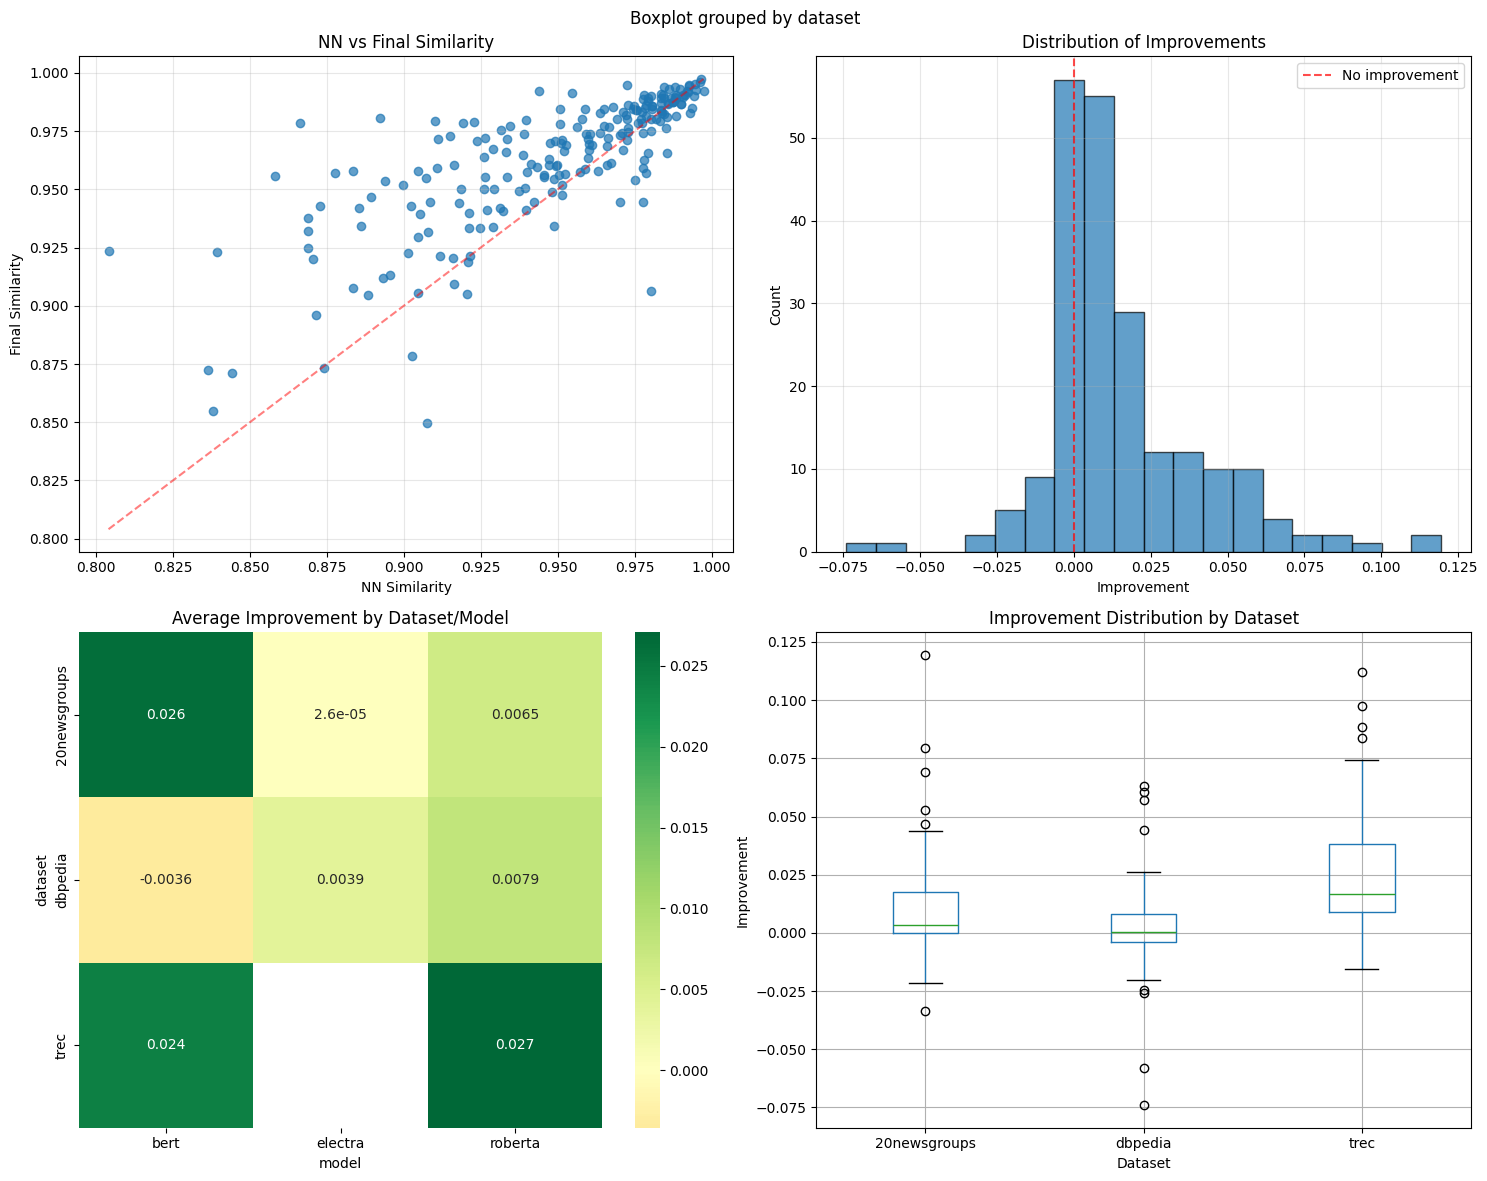


Detailed results saved to: prototype_comparison_results.csv


In [5]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and compare prototypes
pickle_path = 'data/optimization_exp_all_data_seed0.pickle'

if not os.path.exists(pickle_path):
    print(f"Error: File {pickle_path} not found!")
else:
    with open(pickle_path, 'rb') as handle:
        all_exp_data = pickle.load(handle)
    
    print(f"Loaded data from {pickle_path}")
    print(f"Available keys: {list(all_exp_data.keys())}\n")
    
    # Find all experiment keys (not summary keys)
    exp_keys = [k for k in all_exp_data.keys() if not k.endswith('_summary')]
    
    comparison_data = []
    
    for key in exp_keys:
        if 'latent_optim' not in key:
            continue
            
        # Parse dataset/model from key
        parts = key.split('_')
        if len(parts) >= 2:
            dataset = parts[0]
            model = parts[1]
        else:
            dataset, model = "unknown", "unknown"
        
        experiment_data = all_exp_data[key]
        
        print(f"\n{'='*60}")
        print(f"Dataset: {dataset.upper()}, Model: {model.upper()}")
        print(f"{'='*60}")
        
        for i, proto_data in enumerate(experiment_data):
            nn_text = proto_data['early_example']
            nn_similarity = proto_data['early_distance']
            
            optimized_text = proto_data['final_guess']
            final_similarity = proto_data['max_similarity'][-1] if proto_data['max_similarity'] else 0
            
            improvement = final_similarity - nn_similarity
            
            print(f"\nPrototype {i+1}:")
            print(f"  NN Similarity: {nn_similarity:.4f}")
            print(f"  Final Similarity: {final_similarity:.4f}")
            print(f"  Improvement: {improvement:+.4f}")
            print(f"  NN Text: {nn_text}")
            print(f"  Optimized Text: {optimized_text}")
            
            # Store for analysis
            comparison_data.append({
                'dataset': dataset,
                'model': model,
                'prototype': i+1,
                'nn_similarity': nn_similarity,
                'final_similarity': final_similarity,
                'improvement': improvement,
                'nn_text_full': nn_text,
                'optimized_text_full': optimized_text
            })
    
    # Create summary DataFrame
    if comparison_data:
        df = pd.DataFrame(comparison_data)
        
        print(f"\n{'='*80}")
        print("SUMMARY TABLE")
        print(f"{'='*80}")
        display(df[['dataset', 'model', 'prototype', 'nn_similarity', 'final_similarity', 'improvement']])
        
        # Overall statistics
        print(f"\n{'='*80}")
        print("OVERALL STATISTICS")
        print(f"{'='*80}")
        print(f"Average NN Similarity: {df['nn_similarity'].mean():.4f}")
        print(f"Average Final Similarity: {df['final_similarity'].mean():.4f}")
        print(f"Average Improvement: {df['improvement'].mean():.4f}")
        print(f"Best Improvement: {df['improvement'].max():.4f}")
        print(f"Worst Improvement: {df['improvement'].min():.4f}")
        print(f"Positive Improvements: {(df['improvement'] > 0).sum()}/{len(df)} ({100*(df['improvement'] > 0).mean():.1f}%)")
        
        # By dataset/model
        print(f"\nAVERAGE IMPROVEMENT BY DATASET/MODEL:")
        summary_stats = df.groupby(['dataset', 'model'])['improvement'].agg(['mean', 'std', 'count']).round(4)
        display(summary_stats)
        
        # Visualizations
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # 1. Before vs After scatter plot
        axes[0,0].scatter(df['nn_similarity'], df['final_similarity'], alpha=0.7)
        axes[0,0].plot([df['nn_similarity'].min(), df['nn_similarity'].max()], 
                      [df['nn_similarity'].min(), df['nn_similarity'].max()], 'r--', alpha=0.5)
        axes[0,0].set_xlabel('NN Similarity')
        axes[0,0].set_ylabel('Final Similarity')
        axes[0,0].set_title('NN vs Final Similarity')
        axes[0,0].grid(True, alpha=0.3)
        
        # 2. Improvement distribution
        axes[0,1].hist(df['improvement'], bins=20, alpha=0.7, edgecolor='black')
        axes[0,1].axvline(0, color='red', linestyle='--', alpha=0.7, label='No improvement')
        axes[0,1].set_xlabel('Improvement')
        axes[0,1].set_ylabel('Count')
        axes[0,1].set_title('Distribution of Improvements')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
        
        # 3. Improvements by dataset/model
        pivot_data = df.groupby(['dataset', 'model'])['improvement'].mean().reset_index()
        pivot_table = pivot_data.pivot(index='dataset', columns='model', values='improvement')
        sns.heatmap(pivot_table, annot=True, cmap='RdYlGn', center=0, ax=axes[1,0])
        axes[1,0].set_title('Average Improvement by Dataset/Model')
        
        # 4. Box plot of improvements by dataset
        if len(df['dataset'].unique()) > 1:
            df.boxplot(column='improvement', by='dataset', ax=axes[1,1])
            axes[1,1].set_title('Improvement Distribution by Dataset')
            axes[1,1].set_xlabel('Dataset')
            axes[1,1].set_ylabel('Improvement')
        else:
            # If only one dataset, show by model instead
            df.boxplot(column='improvement', by='model', ax=axes[1,1])
            axes[1,1].set_title('Improvement Distribution by Model')
            axes[1,1].set_xlabel('Model')
            axes[1,1].set_ylabel('Improvement')
        
        plt.tight_layout()
        plt.show()
        
        # Save results
        output_path = 'prototype_comparison_results.csv'
        df.to_csv(output_path, index=False)
        print(f"\nDetailed results saved to: {output_path}")
        
    else:
        print("No experiment data found!")